Title=Sales order analysis

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Project Objective

The objective of this project is to analyze food delivery order data and identify
patterns in customer behavior, sales performance, food preferences, delivery
performance, and customer ratings.

The analysis will help us understand the key factors affecting orders, revenue,
customer experience, and delivery operations.

In [2]:
df=pd.read_csv("food_delivery_orders.csv")
df.head()

,order_id,customer_id,restaurant_id,food_item,category,quantity,price,order_date,city,payment_method,payment_status,delivery_status,delivery_time_min,rating
0,ORD100001,C1103,R242,Dosa,South Indian,1,142.0,2026-06-21,Hyderabad,Cash,Paid,Cancelled,41.0,4.3
1,ORD100002,C1436,R261,Dosa,South Indian,4,180.0,2026-01-12,Pune,Cash,Refunded,Delivered,31.0,3.3
2,ORD100003,C1349,R242,Thali,Main Course,3,221.0,2026-05-30,Pune,UPI,Refunded,Delayed,28.0,4.2
3,ORD100004,C1271,R256,Noodles,Asian,1,227.0,2026-03-18,Delhi,Cash,Paid,Delivered,34.0,4.3
4,ORD100005,C1107,R236,Noodles,Asian,1,276.0,2026-08-08,Mumbai,UPI,Paid,Delivered,33.0,5.0


In [3]:
df.tail()

,order_id,customer_id,restaurant_id,food_item,category,quantity,price,order_date,city,payment_method,payment_status,delivery_status,delivery_time_min,rating
3015,ORD102804,C1129,R269,Paneer Tikka,Starters,3,336.0,2026-04-04,Mumbai,UPI,Paid,Delivered,24.0,NaN
3016,ORD102180,C1332,R215,Biryani,Main Course,1,250.0,2026-05-07,Hyderabad,Credit Card,Paid,Delivered,28.0,4.8
3017,ORD101444,C1495,R214,Sandwich,Fast Food,1,215.0,2026-01-11,Pune,Debit Card,Paid,Delayed,NaN,4.2
3018,ORD102265,C1082,R259,Pasta,Fast Food,2,293.0,2026-01-17,Hyderabad,Cash,Failed,Delivered,44.0,3.3
3019,ORD102835,C1289,R254,Sandwich,Fast Food,4,200.0,2026-03-19,Delhi,Debit Card,Paid,Delivered,38.0,4.2


In [4]:
df.columns

Index(['order_id', 'customer_id', 'restaurant_id', 'food_item', 'category',
       'quantity', 'price', 'order_date', 'city', 'payment_method',
       'payment_status', 'delivery_status', 'delivery_time_min', 'rating'],
      dtype='str')

In [5]:
df.dtypes

order_id                 str
customer_id              str
restaurant_id            str
food_item                str
category                 str
quantity               int64
price                float64
order_date               str
city                     str
payment_method           str
payment_status           str
delivery_status          str
delivery_time_min    float64
rating               float64
dtype: object

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3020 entries, 0 to 3019
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           3020 non-null   str    
 1   customer_id        3020 non-null   str    
 2   restaurant_id      3020 non-null   str    
 3   food_item          3020 non-null   str    
 4   category           3020 non-null   str    
 5   quantity           3020 non-null   int64  
 6   price              3020 non-null   float64
 7   order_date         3020 non-null   str    
 8   city               3020 non-null   str    
 9   payment_method     3020 non-null   str    
 10  payment_status     3020 non-null   str    
 11  delivery_status    3020 non-null   str    
 12  delivery_time_min  2974 non-null   float64
 13  rating             2899 non-null   float64
dtypes: float64(3), int64(1), str(10)
memory usage: 330.4 KB


In [7]:
df.shape

(3020, 14)

In [8]:
df.describe()

,quantity,price,delivery_time_min,rating
count,3020.000000,3020.000000,2974.000000,2899.000000
mean,1.983113,281.114901,32.130464,4.086064
std,1.075817,81.966278,9.555217,0.606457
min,1.000000,136.000000,12.000000,2.000000
25%,1.000000,218.000000,26.000000,3.700000
50%,2.000000,273.000000,32.000000,4.100000
75%,3.000000,333.000000,39.000000,4.600000
max,4.000000,503.000000,65.000000,5.000000


In [9]:
df.isna().any()

order_id             False
customer_id          False
restaurant_id        False
food_item            False
category             False
quantity             False
price                False
order_date           False
city                 False
payment_method       False
payment_status       False
delivery_status      False
delivery_time_min     True
rating                True
dtype: bool

In [10]:
df.isna().sum()

order_id               0
customer_id            0
restaurant_id          0
food_item              0
category               0
quantity               0
price                  0
order_date             0
city                   0
payment_method         0
payment_status         0
delivery_status        0
delivery_time_min     46
rating               121
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(20)

In [12]:
check = df.select_dtypes(include="object").columns

for i in check:
    print(i)
    print(df[i].value_counts())
    print()

order_id
order_id
ORD100569    2
ORD100719    2
ORD100892    2
ORD101112    2
ORD101124    2
            ..
ORD102996    1
ORD102997    1
ORD102998    1
ORD102999    1
ORD103000    1
Name: count, Length: 3000, dtype: int64

customer_id
customer_id
C1039    15
C1446    14
C1459    13
C1485    13
C1289    13
         ..
C1091     1
C1030     1
C1479     1
C1421     1
C1071     1
Name: count, Length: 499, dtype: int64

restaurant_id
restaurant_id
R221    60
R213    52
R259    50
R247    49
R217    49
        ..
R218    29
R277    29
R231    29
R207    27
R271    24
Name: count, Length: 80, dtype: int64

food_item
food_item
Chicken Curry    331
Noodles          330
Pizza            330
Thali            313
Dosa             294
Burger           294
Pasta            292
Paneer Tikka     287
Biryani          279
Sandwich         270
Name: count, dtype: int64

category
category
Fast Food       1186
Main Course      923
Asian            330
South Indian     294
Starters         287
Name: count,

/var/folders/vy/r0ngfr6x6rq3p90hkkd06k840000gn/T/ipykernel_3696/503599501.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  check = df.select_dtypes(include="object").columns


In [13]:
df[df["delivery_time_min"].isna()]["delivery_status"].value_counts()

delivery_status
Delivered    29
Cancelled    10
Delayed       7
Name: count, dtype: int64

In [14]:
df[df["rating"].isna()]["delivery_status"].value_counts()

delivery_status
Delivered    79
Cancelled    22
Delayed      20
Name: count, dtype: int64

In [15]:
df[df["delivery_time_min"].isna()]["payment_status"].value_counts()

payment_status
Paid        31
Failed      11
Refunded     4
Name: count, dtype: int64

In [16]:
df[df["rating"].isna()]["payment_status"].value_counts()

payment_status
Paid        95
Failed      14
Refunded    12
Name: count, dtype: int64

In [17]:
df1=df.drop_duplicates()
df1.duplicated()


0       False
1       False
2       False
3       False
4       False
        ...  
2995    False
2996    False
2997    False
2998    False
2999    False
Length: 3000, dtype: bool

In [18]:
df1.shape

(3000, 14)

In [19]:
df1.isna().sum()

order_id               0
customer_id            0
restaurant_id          0
food_item              0
category               0
quantity               0
price                  0
order_date             0
city                   0
payment_method         0
payment_status         0
delivery_status        0
delivery_time_min     45
rating               120
dtype: int64

In [20]:
df1["rating"].value_counts().sort_index()

rating
2.0      3
2.1      2
2.2      2
2.3      4
2.4      4
2.5     11
2.6      5
2.7     11
2.8     33
2.9     31
3.0     32
3.1     55
3.2     78
3.3     86
3.4    110
3.5    113
3.6    126
3.7    127
3.8    168
3.9    172
4.0    152
4.1    181
4.2    180
4.3    136
4.4    148
4.5    177
4.6    129
4.7    130
4.8    108
4.9     86
5.0    280
Name: count, dtype: int64

In [21]:
df1["delivery_time_min"].describe()


count    2955.000000
mean       32.114044
std         9.561768
min        12.000000
25%        26.000000
50%        32.000000
75%        39.000000
max        65.000000
Name: delivery_time_min, dtype: float64

In [22]:
df1["delivery_time_min"]=df1["delivery_time_min"].fillna(df1["delivery_time_min"].median())
df1.isna().sum()

order_id               0
customer_id            0
restaurant_id          0
food_item              0
category               0
quantity               0
price                  0
order_date             0
city                   0
payment_method         0
payment_status         0
delivery_status        0
delivery_time_min      0
rating               120
dtype: int64

In [23]:
df1[df1["rating"].isna()]["delivery_status"].value_counts()


delivery_status
Delivered    78
Cancelled    22
Delayed      20
Name: count, dtype: int64

In [24]:
df1.select_dtypes(include="number").columns

Index(['quantity', 'price', 'delivery_time_min', 'rating'], dtype='str')

In [25]:
df1[["quantity", "price", "delivery_time_min", "rating"]].describe()

,quantity,price,delivery_time_min,rating
count,3000.000000,3000.000000,3000.000000,2880.000000
mean,1.982000,281.190000,32.112333,4.087083
std,1.075203,82.111798,9.489770,0.606329
min,1.000000,136.000000,12.000000,2.000000
25%,1.000000,218.000000,26.000000,3.700000
50%,2.000000,273.000000,32.000000,4.100000
75%,3.000000,333.250000,39.000000,4.600000
max,4.000000,503.000000,65.000000,5.000000


In [26]:
check1=df1.select_dtypes(include="object").columns

/var/folders/vy/r0ngfr6x6rq3p90hkkd06k840000gn/T/ipykernel_3696/1890812993.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  check1=df1.select_dtypes(include="object").columns


In [27]:
for j in check1:
    print(j)
    print(df1[j].value_counts())
    print()

order_id
order_id
ORD100001    1
ORD100002    1
ORD100003    1
ORD100004    1
ORD100005    1
            ..
ORD102996    1
ORD102997    1
ORD102998    1
ORD102999    1
ORD103000    1
Name: count, Length: 3000, dtype: int64

customer_id
customer_id
C1039    15
C1459    13
C1446    13
C1497    13
C1264    12
         ..
C1091     1
C1030     1
C1479     1
C1421     1
C1071     1
Name: count, Length: 499, dtype: int64

restaurant_id
restaurant_id
R221    59
R213    52
R217    49
R247    48
R228    48
        ..
R277    29
R214    29
R207    27
R231    27
R271    24
Name: count, Length: 80, dtype: int64

food_item
food_item
Pizza            330
Noodles          329
Chicken Curry    329
Thali            310
Dosa             293
Burger           291
Pasta            289
Paneer Tikka     284
Biryani          278
Sandwich         267
Name: count, dtype: int64

category
category
Fast Food       1177
Main Course      917
Asian            329
South Indian     293
Starters         284
Name: count,

In [28]:
df1["delivery_status"].value_counts()

delivery_status
Delivered    1975
Cancelled     533
Delayed       492
Name: count, dtype: int64

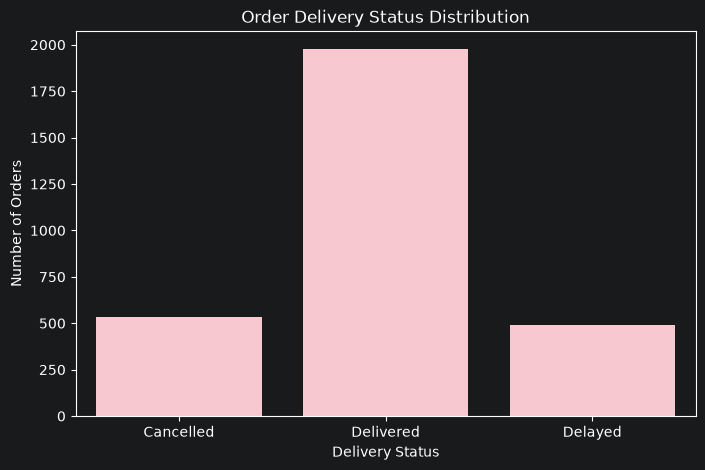

In [29]:
plt.figure(figsize=(8,5))
sns.countplot(data=df1, x="delivery_status", color="pink")
plt.title("Order Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.show()

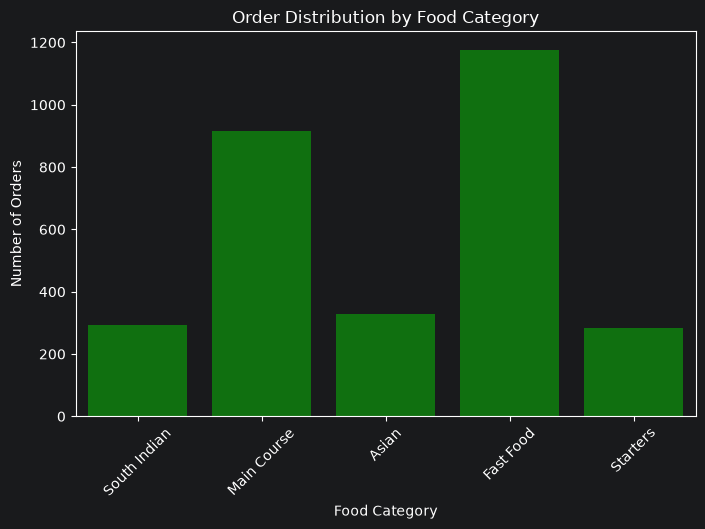

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(data=df1, x="category", color="green")
plt.title("Order Delivery Status Distribution")

plt.title("Order Distribution by Food Category")
plt.xlabel("Food Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

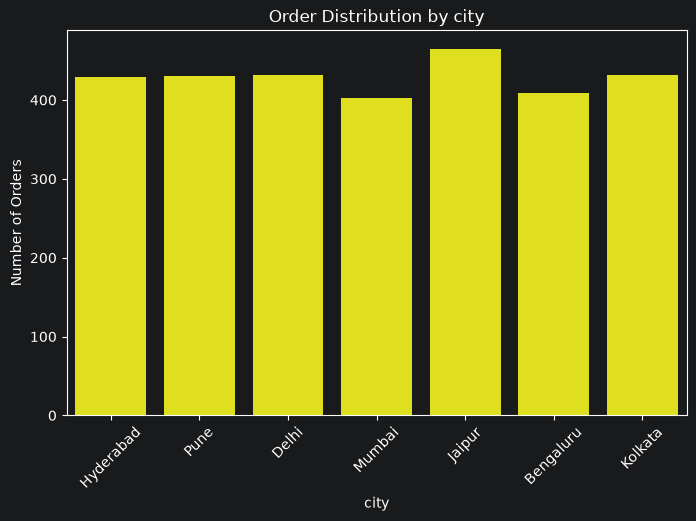

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(data=df1, x="city", color="yellow")
plt.title("Order Delivery Status Distribution")
plt.title("Order Distribution by city")
plt.xlabel("city")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

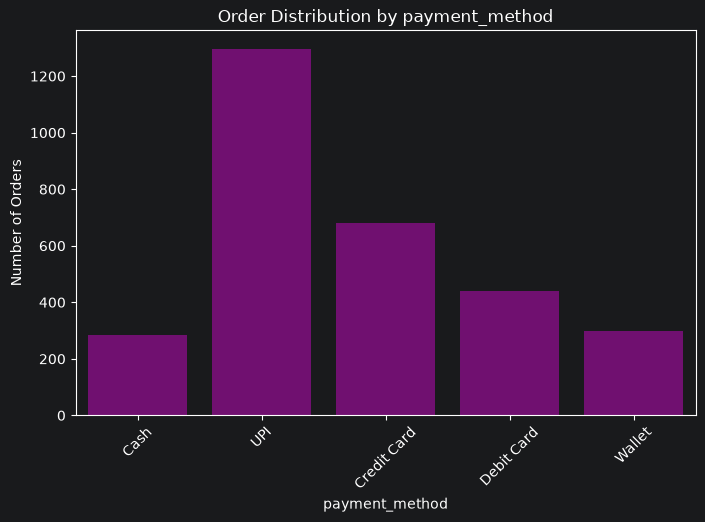

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(data=df1, x="payment_method", color="purple")
plt.title("Order Distribution by payment_method")
plt.xlabel("payment_method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

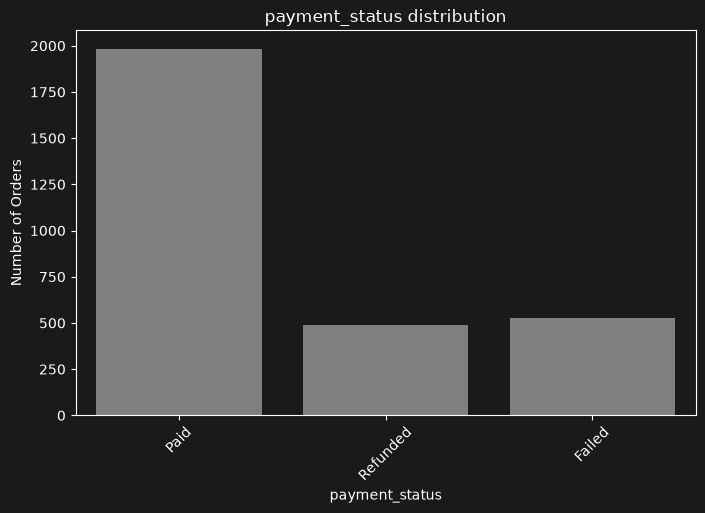

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(data=df1, x="payment_status", color="grey")
plt.title("payment_status distribution")
plt.xlabel("payment_status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

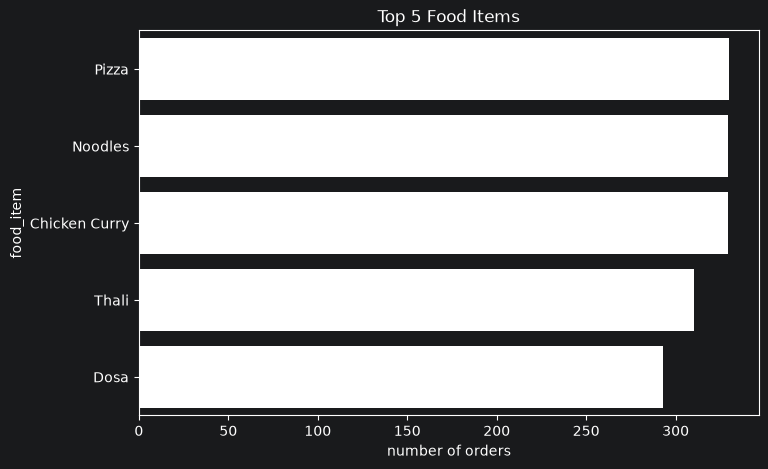

In [34]:
top_food=df1["food_item"].value_counts().sort_values(ascending=False).head(5)
plt.figure(figsize=(8,5))
sns.barplot(x=top_food.values, y=top_food.index,color="white")
plt.title("Top 5 Food Items")
plt.xlabel("number of orders")
plt.ylabel("food_item")
plt.show()


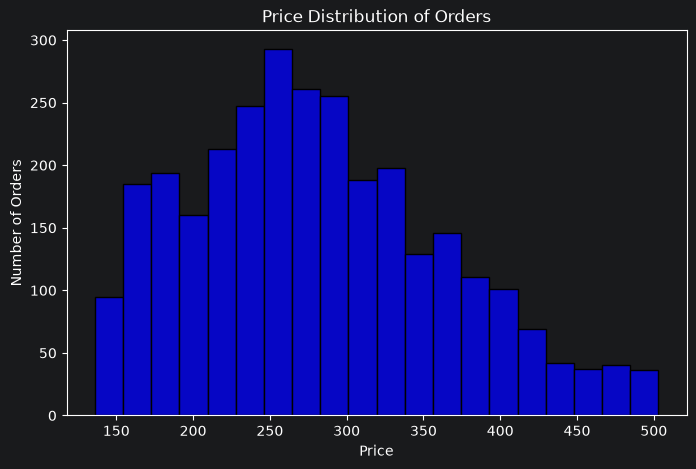

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(data=df1, x="price", bins=20, color="blue")

plt.title("Price Distribution of Orders")
plt.xlabel("Price")
plt.ylabel("Number of Orders")

plt.show()

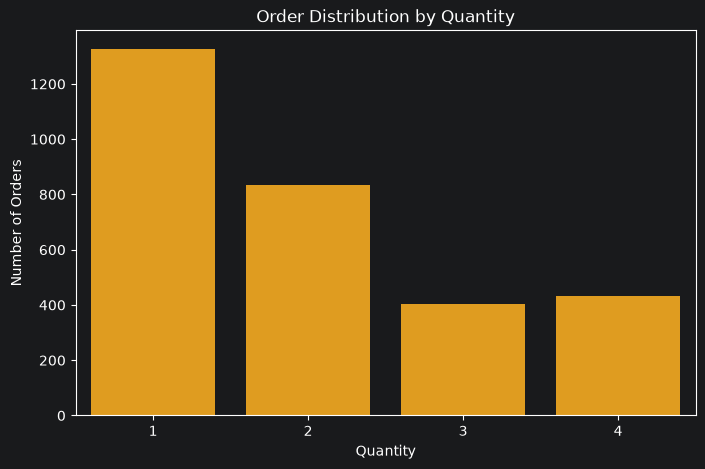

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(data=df1, x="quantity", color="orange")

plt.title("Order Distribution by Quantity")
plt.xlabel("Quantity")
plt.ylabel("Number of Orders")

plt.show()

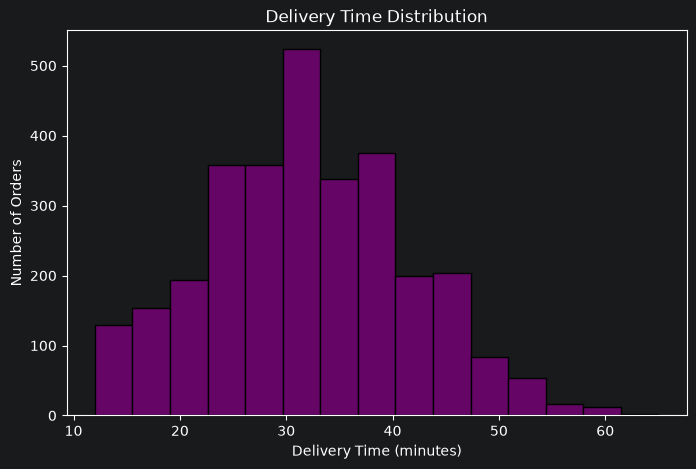

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(data=df1, x="delivery_time_min", bins=15, color="purple")

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Orders")

plt.show()

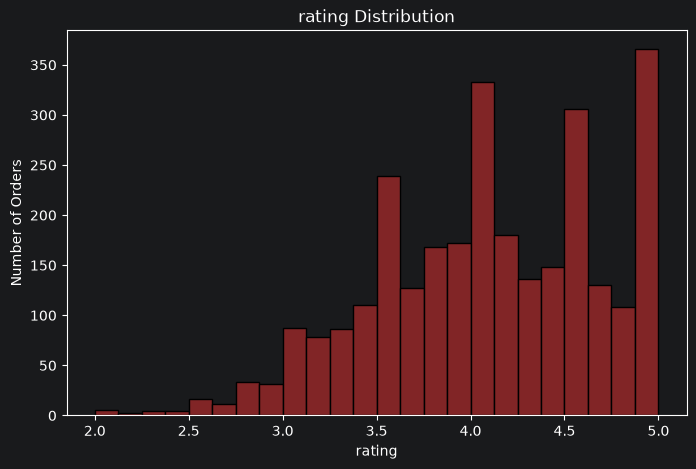

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(data=df1, x="rating",color="brown")
plt.title("rating Distribution")
plt.xlabel("rating")
plt.ylabel("Number of Orders")

plt.show()

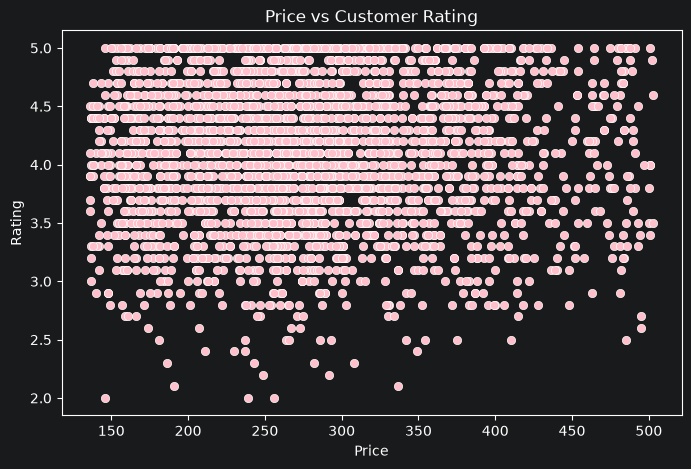

In [39]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df1, x="price", y="rating",color="pink")

plt.title("Price vs Customer Rating")
plt.xlabel("Price")
plt.ylabel("Rating")

plt.show()

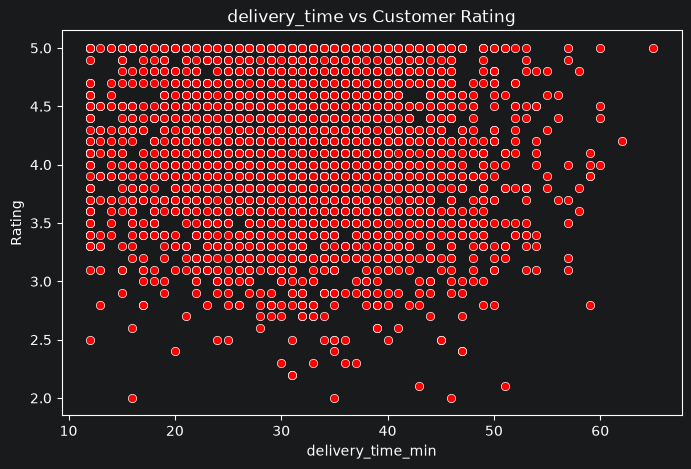

In [40]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df1, x="delivery_time_min", y="rating",color="red")

plt.title("delivery_time vs Customer Rating")
plt.xlabel("delivery_time_min")
plt.ylabel("Rating")

plt.show()

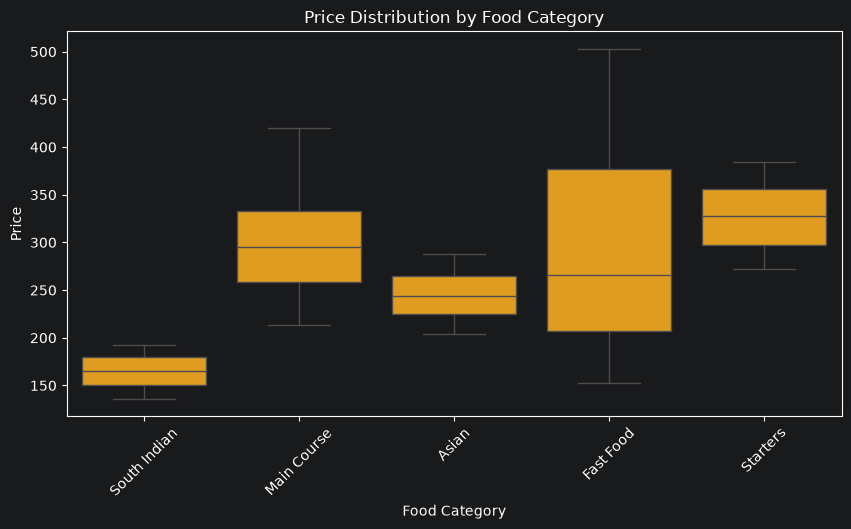

In [41]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df1, x="category", y="price", color="orange")

plt.title("Price Distribution by Food Category")
plt.xlabel("Food Category")
plt.ylabel("Price")

plt.xticks(rotation=45)
plt.show()

In [42]:
correlation = df1[["quantity", "price", "delivery_time_min", "rating"]].corr()

print(correlation)

                   quantity     price  delivery_time_min    rating
quantity           1.000000 -0.009226           0.002486  0.007172
price             -0.009226  1.000000          -0.007251  0.013332
delivery_time_min  0.002486 -0.007251           1.000000 -0.014809
rating             0.007172  0.013332          -0.014809  1.000000


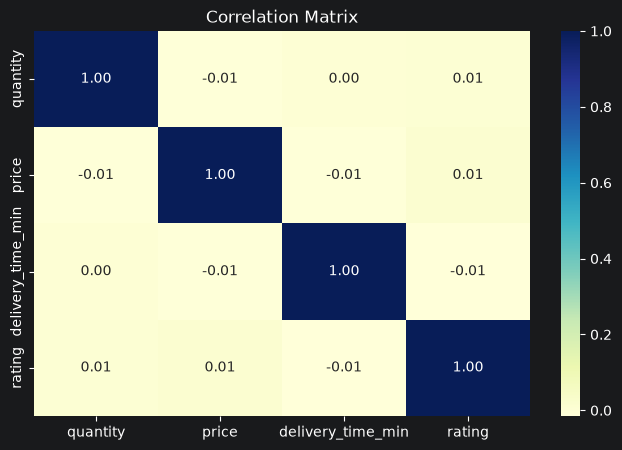

In [43]:
plt.figure(figsize=(8,5))
sns.heatmap(correlation,annot=True,cmap="YlGnBu",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [44]:
df1["revenue"] = df1["quantity"] * df1["price"]

In [45]:
df1[["quantity", "price", "revenue"]].head()

,quantity,price,revenue
0,1,142.0,142.0
1,4,180.0,720.0
2,3,221.0,663.0
3,1,227.0,227.0
4,1,276.0,276.0


In [46]:
total_revenue = df1["revenue"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 1669513.0


In [47]:
average_order_value = df1["revenue"].mean()

print("Average Order Value:", average_order_value)

Average Order Value: 556.5043333333333


In [48]:
category_revenue = df1.groupby("category")["revenue"].sum().sort_values(ascending=False)

print(category_revenue)

category
Fast Food       682638.0
Main Course     551071.0
Starters        178569.0
Asian           163270.0
South Indian     93965.0
Name: revenue, dtype: float64


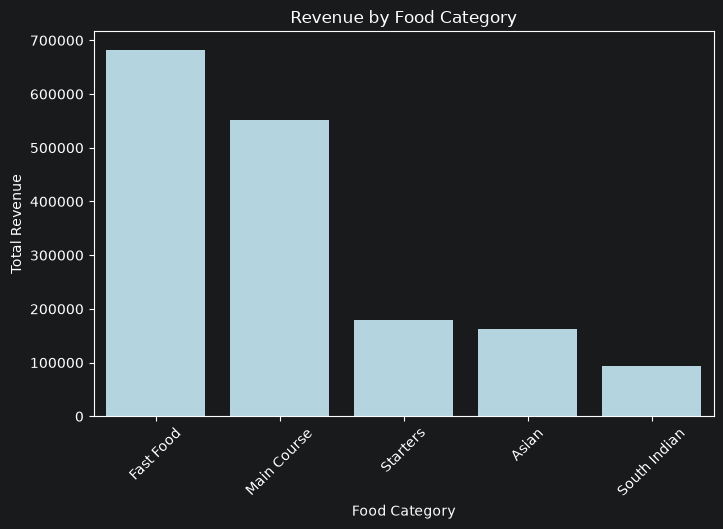

In [69]:
plt.figure(figsize=(8,5))

sns.barplot(x=category_revenue.index,y=category_revenue.values,color="lightblue")
plt.title("Revenue by Food Category")
plt.xlabel("Food Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.show()

In [52]:
city_revenue = df1.groupby("city")["revenue"].sum().sort_values(ascending=False)

print(city_revenue)

city
Kolkata      248521.0
Jaipur       244919.0
Delhi        242710.0
Pune         241299.0
Hyderabad    240506.0
Mumbai       227025.0
Bengaluru    224533.0
Name: revenue, dtype: float64


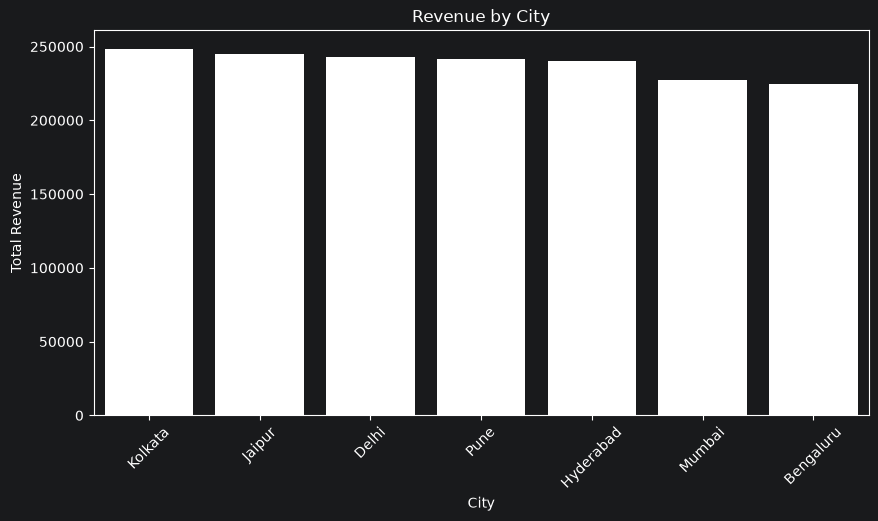

In [54]:
plt.figure(figsize=(10,5))

sns.barplot(x=city_revenue.index,y=city_revenue.values,color="white")

plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.show()

In [55]:
food_revenue = df1.groupby("food_item")["revenue"].sum().sort_values(ascending=False).head(5)

print(food_revenue)

food_item
Pizza            281399.0
Chicken Curry    235325.0
Paneer Tikka     178569.0
Pasta            169767.0
Noodles          163270.0
Name: revenue, dtype: float64


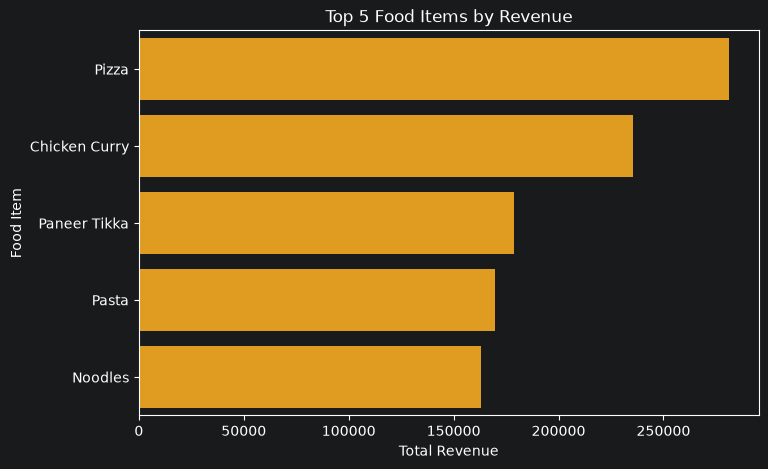

In [57]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=food_revenue.values,
    y=food_revenue.index,
    color="orange"
)

plt.title("Top 5 Food Items by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Food Item")

plt.show()

In [60]:
df1.head()

,order_id,customer_id,restaurant_id,food_item,category,quantity,price,order_date,city,payment_method,payment_status,delivery_status,delivery_time_min,rating,revenue
0,ORD100001,C1103,R242,Dosa,South Indian,1,142.0,2026-06-21,Hyderabad,Cash,Paid,Cancelled,41.0,4.3,142.0
1,ORD100002,C1436,R261,Dosa,South Indian,4,180.0,2026-01-12,Pune,Cash,Refunded,Delivered,31.0,3.3,720.0
2,ORD100003,C1349,R242,Thali,Main Course,3,221.0,2026-05-30,Pune,UPI,Refunded,Delayed,28.0,4.2,663.0
3,ORD100004,C1271,R256,Noodles,Asian,1,227.0,2026-03-18,Delhi,Cash,Paid,Delivered,34.0,4.3,227.0
4,ORD100005,C1107,R236,Noodles,Asian,1,276.0,2026-08-08,Mumbai,UPI,Paid,Delivered,33.0,5.0,276.0


In [63]:
df1["order_date"] = pd.to_datetime(df1["order_date"])

In [59]:
df1["order_date"].dtype

dtype('<M8[us]')

In [66]:
df1["month"] = df1["order_date"].dt.month
df1.head()

,order_id,customer_id,restaurant_id,food_item,category,quantity,price,order_date,city,payment_method,payment_status,delivery_status,delivery_time_min,rating,revenue,month
0,ORD100001,C1103,R242,Dosa,South Indian,1,142.0,2026-06-21,Hyderabad,Cash,Paid,Cancelled,41.0,4.3,142.0,6
1,ORD100002,C1436,R261,Dosa,South Indian,4,180.0,2026-01-12,Pune,Cash,Refunded,Delivered,31.0,3.3,720.0,1
2,ORD100003,C1349,R242,Thali,Main Course,3,221.0,2026-05-30,Pune,UPI,Refunded,Delayed,28.0,4.2,663.0,5
3,ORD100004,C1271,R256,Noodles,Asian,1,227.0,2026-03-18,Delhi,Cash,Paid,Delivered,34.0,4.3,227.0,3
4,ORD100005,C1107,R236,Noodles,Asian,1,276.0,2026-08-08,Mumbai,UPI,Paid,Delivered,33.0,5.0,276.0,8


In [67]:
monthly_orders = df1.groupby("month")["order_id"].count()

print(monthly_orders)

month
1    417
2    330
3    373
4    360
5    379
6    384
7    383
8    374
Name: order_id, dtype: int64


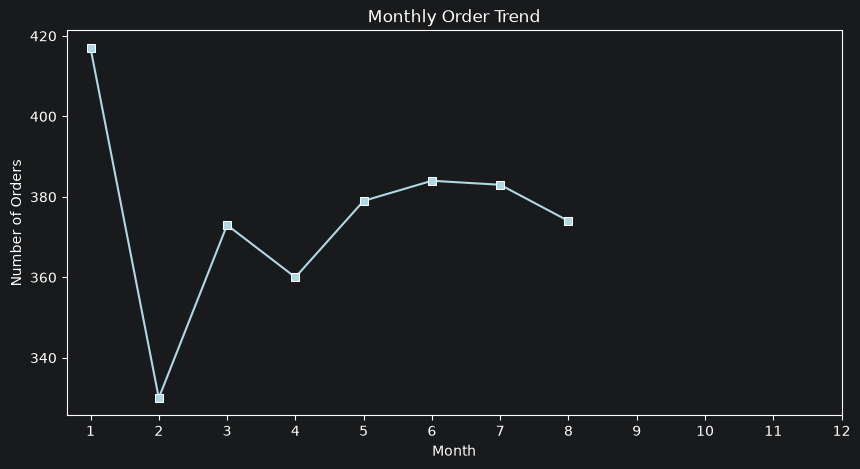

In [72]:
plt.figure(figsize=(10,5))

sns.lineplot(x=monthly_orders.index,y=monthly_orders.values, marker="s",color="lightblue")
plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(range(1, 13))

plt.show()

In [73]:
monthly_revenue = df1.groupby("month")["revenue"].sum()

print(monthly_revenue)

month
1    227025.0
2    177006.0
3    203362.0
4    194807.0
5    225194.0
6    204559.0
7    227741.0
8    209819.0
Name: revenue, dtype: float64


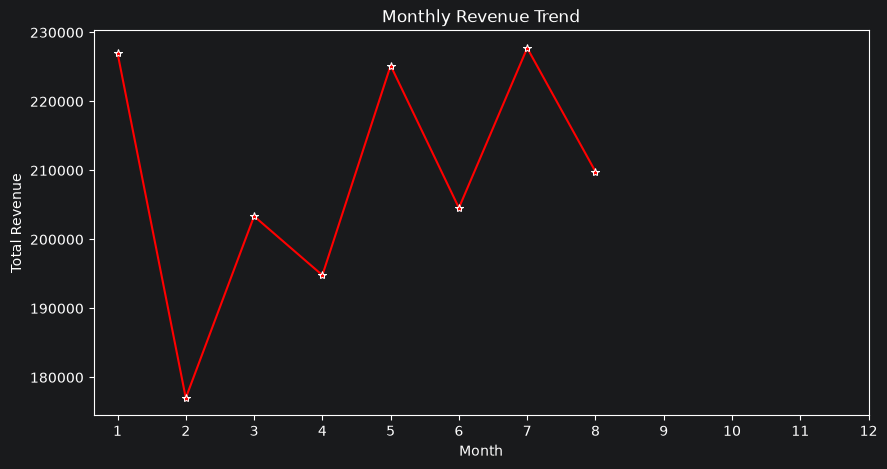

In [78]:
plt.figure(figsize=(10,5))

sns.lineplot(x=monthly_revenue.index,y=monthly_revenue.values,marker="*",color="red")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(range(1, 13))

plt.show()

In [79]:
restaurant_revenue = df1.groupby("restaurant_id")["revenue"].sum().sort_values(ascending=False).head(10)

print(restaurant_revenue)

restaurant_id
R221    33280.0
R247    30447.0
R217    30020.0
R259    29406.0
R213    28094.0
R210    27222.0
R211    26530.0
R235    26245.0
R254    25707.0
R228    25692.0
Name: revenue, dtype: float64


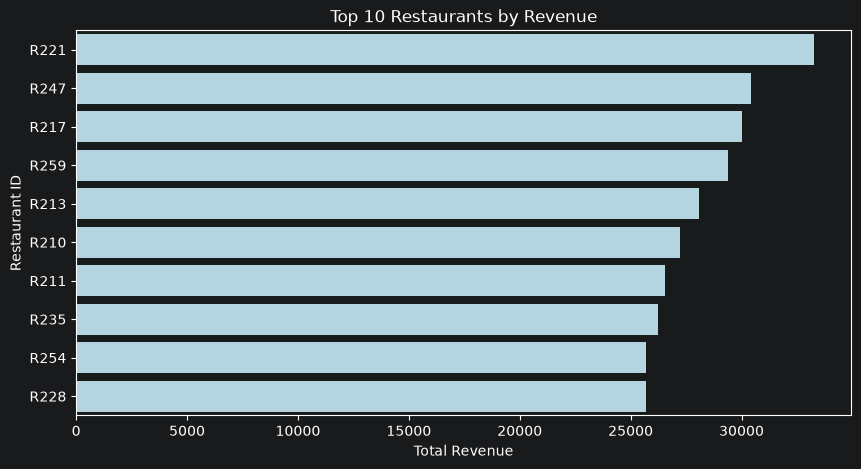

In [81]:
plt.figure(figsize=(10,5))

sns.barplot(x=restaurant_revenue.values,y=restaurant_revenue.index,color="lightblue")

plt.title("Top 10 Restaurants by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Restaurant ID")

plt.show()

In [82]:
top_customers = df1["customer_id"].value_counts().head(10)

print(top_customers)

customer_id
C1039    15
C1459    13
C1446    13
C1497    13
C1264    12
C1289    12
C1293    12
C1318    12
C1435    12
C1012    12
Name: count, dtype: int64


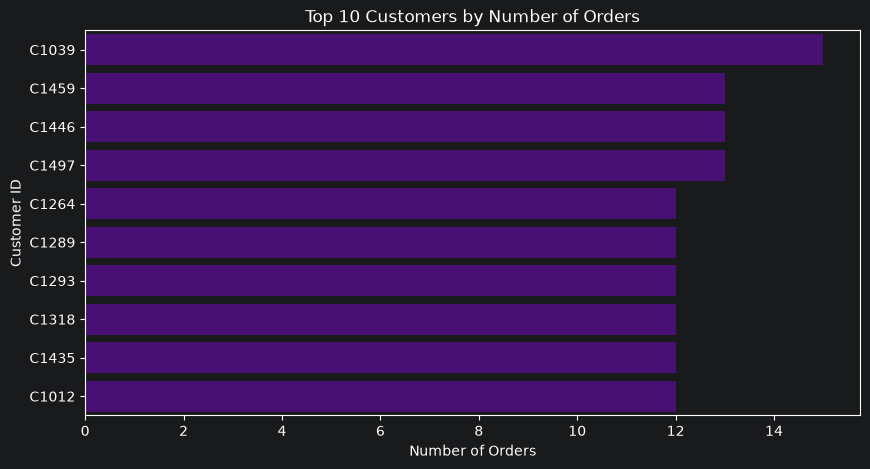

In [84]:
plt.figure(figsize=(10,5))

sns.barplot(x=top_customers.values,y=top_customers.index,color="indigo")

plt.title("Top 10 Customers by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Customer ID")

plt.show()

In [85]:
top_customer_revenue = df1.groupby("customer_id")["revenue"].sum().sort_values(ascending=False).head(10)

print(top_customer_revenue)

customer_id
C1039    9322.0
C1459    8640.0
C1198    7988.0
C1435    7870.0
C1285    7560.0
C1365    7543.0
C1446    7417.0
C1239    7276.0
C1042    7116.0
C1289    7024.0
Name: revenue, dtype: float64


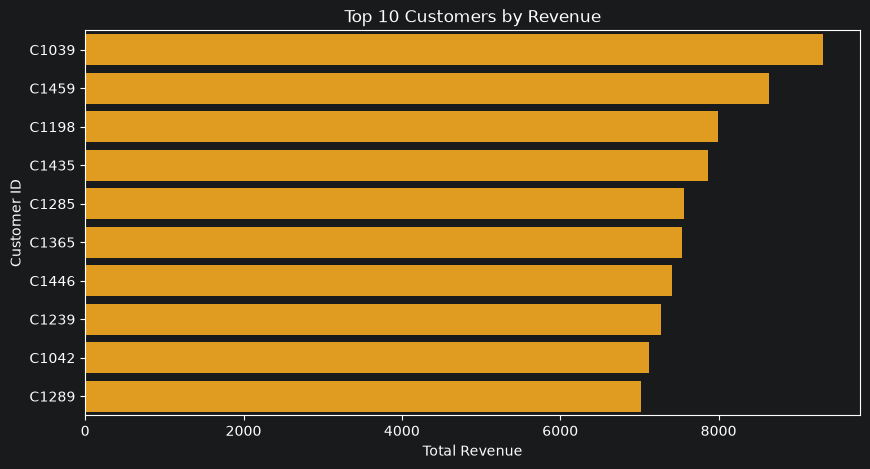

In [87]:
plt.figure(figsize=(10,5))

sns.barplot( x=top_customer_revenue.values,y=top_customer_revenue.index,color="orange")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Customer ID")

plt.show()

In [95]:
problem_orders = df1[df1["delivery_status"].isin(["Cancelled", "Delayed"])]

print(problem_orders["delivery_status"].value_counts())

delivery_status
Cancelled    533
Delayed      492
Name: count, dtype: int64


In [98]:
problem_order_percentage = (len(problem_orders) / len(df1)) * 100

print("Problem Order Percentage:", problem_order_percentage)

Problem Order Percentage: 34.166666666666664


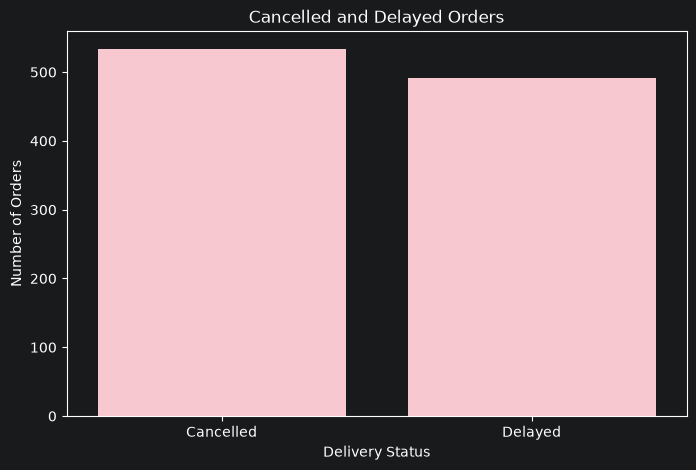

In [100]:
plt.figure(figsize=(8,5))

sns.countplot(data=problem_orders,x="delivery_status",color="pink")

plt.title("Cancelled and Delayed Orders")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")

plt.show()

In [101]:
problem_revenue = problem_orders.groupby("delivery_status")["revenue"].sum()

print(problem_revenue)

delivery_status
Cancelled    294126.0
Delayed      267721.0
Name: revenue, dtype: float64


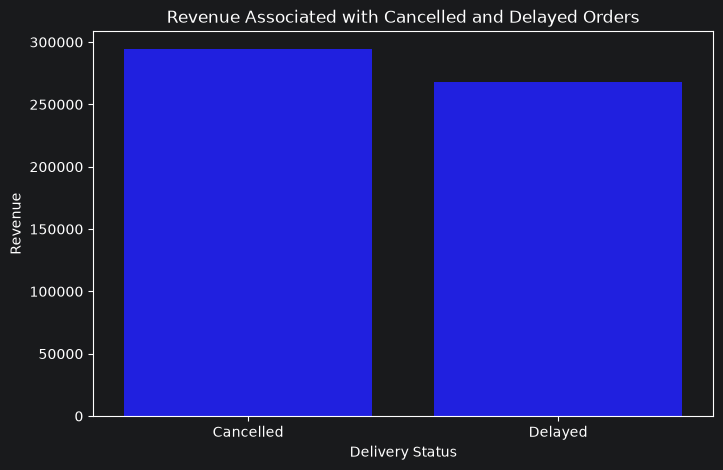

In [103]:
plt.figure(figsize=(8,5))

sns.barplot(x=problem_revenue.index,y=problem_revenue.values,color="blue")

plt.title("Revenue Associated with Cancelled and Delayed Orders")
plt.xlabel("Delivery Status")
plt.ylabel("Revenue")

plt.show()

In [104]:
payment_revenue = df1.groupby("payment_status")["revenue"].sum()

print(payment_revenue)

payment_status
Failed       288862.0
Paid        1105398.0
Refunded     275253.0
Name: revenue, dtype: float64


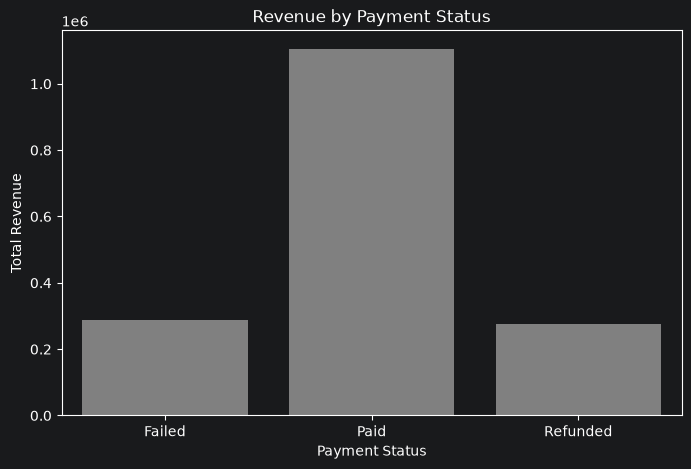

In [106]:
plt.figure(figsize=(8,5))

sns.barplot(x=payment_revenue.index,y=payment_revenue.values,color="grey")

plt.title("Revenue by Payment Status")
plt.xlabel("Payment Status")
plt.ylabel("Total Revenue")

plt.show()

In [109]:
status_payment = pd.crosstab(df1["payment_status"],df1["delivery_status"])
print(status_payment)

delivery_status  Cancelled  Delayed  Delivered
payment_status                                
Failed                  76       82        369
Paid                   357      322       1305
Refunded               100       88        301


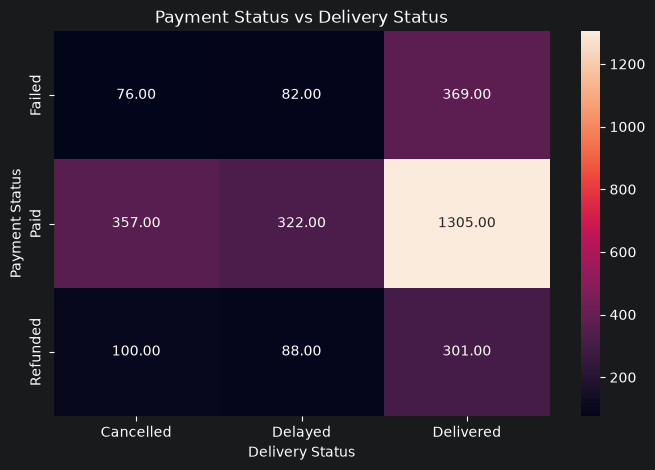

In [112]:
plt.figure(figsize=(8,5))

sns.heatmap(status_payment, annot=True,fmt=".2f")

plt.title("Payment Status vs Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Payment Status")

plt.show()

In [113]:
top_restaurants_orders = df1["restaurant_id"].value_counts().head(10)

print(top_restaurants_orders)

restaurant_id
R221    59
R213    52
R217    49
R247    48
R228    48
R259    48
R249    46
R232    46
R208    46
R268    44
Name: count, dtype: int64


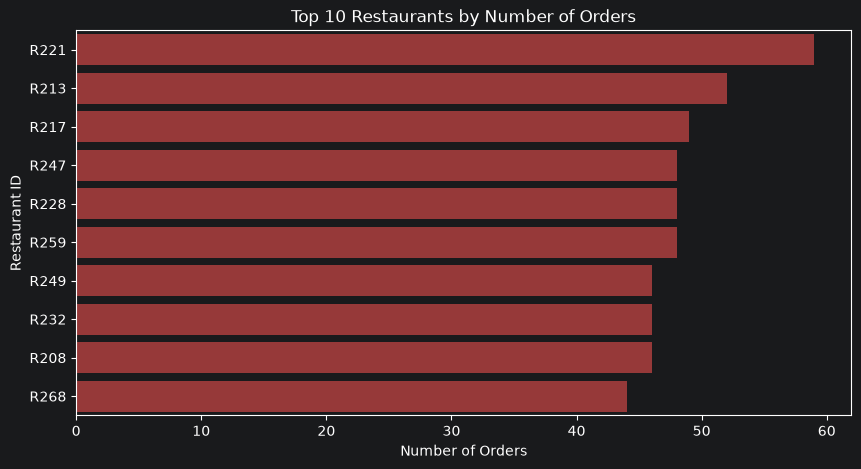

In [115]:
plt.figure(figsize=(10,5))

sns.barplot(x=top_restaurants_orders.values,y=top_restaurants_orders.index,color="brown")

plt.title("Top 10 Restaurants by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Restaurant ID")

plt.show()

In [116]:
order_frequency = df1["customer_id"].value_counts()

frequency_groups = pd.cut(
    order_frequency,
    bins=[0, 1, 3, float("inf")],
    labels=["1 Order", "2-3 Orders", "4+ Orders"]
)

print(frequency_groups.value_counts())

count
4+ Orders     408
2-3 Orders     84
1 Order         7
Name: count, dtype: int64


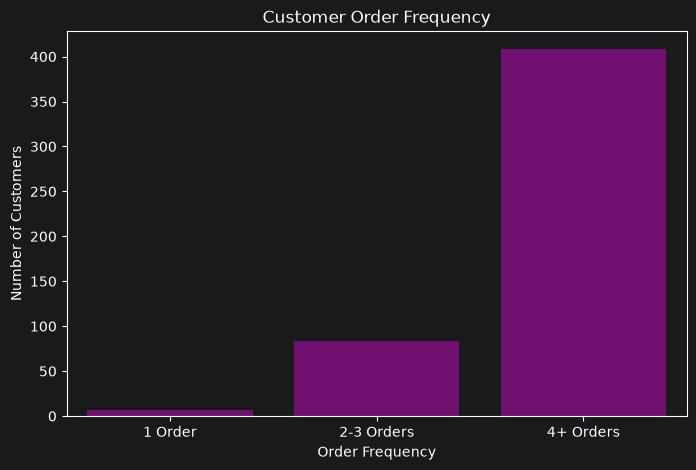

In [118]:
plt.figure(figsize=(8,5))

sns.countplot(x=frequency_groups,color="purple")

plt.title("Customer Order Frequency")
plt.xlabel("Order Frequency")
plt.ylabel("Number of Customers")

plt.show()

In [119]:
df1[["quantity", "price", "delivery_time_min", "rating", "revenue"]].describe()

,quantity,price,delivery_time_min,rating,revenue
count,3000.000000,3000.000000,3000.000000,2880.000000,3000.000000
mean,1.982000,281.190000,32.112333,4.087083,556.504333
std,1.075203,82.111798,9.489770,0.606329,351.548545
min,1.000000,136.000000,12.000000,2.000000,136.000000
25%,1.000000,218.000000,26.000000,3.700000,285.000000
50%,2.000000,273.000000,32.000000,4.100000,444.500000
75%,3.000000,333.250000,39.000000,4.600000,748.000000
max,4.000000,503.000000,65.000000,5.000000,1988.000000


In [120]:
category_revenue.idxmax(), category_revenue.max()

('Fast Food', np.float64(682638.0))

In [121]:
city_revenue.idxmax(), city_revenue.max()

('Kolkata', np.float64(248521.0))

In [122]:
df1["food_item"].value_counts().idxmax(), df1["food_item"].value_counts().max()

('Pizza', np.int64(330))

In [123]:
df1["delivery_status"].value_counts().idxmax(), df1["delivery_status"].value_counts().max()

('Delivered', np.int64(1975))

In [124]:
delivery_percentage = df1["delivery_status"].value_counts(normalize=True) * 100

print(delivery_percentage)

delivery_status
Delivered    65.833333
Cancelled    17.766667
Delayed      16.400000
Name: proportion, dtype: float64


In [125]:
payment_percentage = df1["payment_status"].value_counts(normalize=True) * 100

print(payment_percentage)

payment_status
Paid        66.133333
Failed      17.566667
Refunded    16.300000
Name: proportion, dtype: float64


## key business insights

#The dataset contains 3,000 orders after duplicate removal.

#The average order quantity is approximately 1.98 items per order.

#The average order price is approximately 281.19.

#The average delivery time is approximately 32.11 minutes.

#The average customer rating is approximately 4.09 out of 5 based on available ratings.

#The average revenue generated per order is approximately 556.50.


#Order-level revenue ranges from 136 to 1,988.

## Business Recommendations

#Focus on improving delivery performance, especially for delayed orders.

#Monitor cancelled orders regularly to identify operational issues.

#Identify high-revenue food categories and strengthen their availability and promotion.

#Give attention to high-performing cities and restaurants to maintain their revenue contribution.

#Use customer order-frequency data to identify repeat customers and develop suitable retention strategies.

#Monitor customer ratings along with delivery time to improve overall customer experience.

#Use monthly order and revenue trends for demand planning and resource allocation.

## Conclusion

This project analyzed 3,000 food delivery orders to understand order patterns, customer behavior, revenue performance, payment activity, and delivery operations. The analysis used Python, NumPy, Pandas, Matplotlib, Seaborn, and statistical methods to clean the data, explore trends, identify relationships, and generate business insights. The findings can help a food delivery business understand its customers, monitor operational performance, identify revenue opportunities, and make data-driven business decisions.